In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS
from tqdm import tqdm
from model_components.models import *
from model_components.old_model import *
from model_components.util import *
import scipy.io
import numpy as np
from scipy.fft import fft, fftfreq

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform(m.weight)
        m.bias.data.fill_(0.01)

In [3]:
class DecoderOnlyPINNsformerSpaceTime(nn.Module):
    def __init__(self, d_out, d_model, d_hidden, N, heads, d_in, mapping_size):
        super(DecoderOnlyPINNsformerSpaceTime, self).__init__()

        self.in_features = d_in
        self.spatial_features = d_in - 1
        self.time_features = 1
        self.fourier_emb = nn.Linear(2 * mapping_size, d_model)
        self.time_emb = nn.Linear(self.in_features, d_model)
        self.test_emb = nn.Linear(self.in_features, d_model)  # For testing purposes, if needed
        

        self.decoder = Decoder(d_model, N, heads)
        self.linear_out = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            WaveAct(),
            nn.Linear(d_hidden, d_hidden),
            WaveAct(),
            nn.Linear(d_hidden, d_out)
        )
        
        # Add a random matrix B that is (in_features x mapping_size), and cannot be learned.
        self.register_buffer('B', torch.randn(self.in_features, mapping_size))
        

    def forward(self, x, t):
        x_norm = x / (2 * torch.pi)
        t_norm = t / 1.0
        spacetime = torch.cat([x_norm, t_norm], dim=-1)
        src = 2 * torch.pi * spacetime @ self.B  # (batch_size, seq_len, mapping_size)
        f = torch.cat([src.sin(), src.cos()], dim=-1)  # (batch, seq_len, 2*mapping_size)
        token_emb = self.fourier_emb(f)  # (batch_size, seq_len
        # token_emb = self.test_emb(spacetime)  # For testing purposes, if needed
        pos_emb = self.time_emb(spacetime)

        out = token_emb + pos_emb

        d_output = self.decoder(out, out)  # decoder attends to input only
        output = self.linear_out(d_output)
        return output

In [4]:
res_test, _, _, _, _ = get_data([0,2*np.pi], [0,1], 101, 101)
res_test = make_time_sequence(res_test, num_step=5, step=1e-4) 
res_test = torch.tensor(res_test, dtype=torch.float32, requires_grad=True).to(device)
x_test, t_test = res_test[:,:,0:1], res_test[:,:,1:2]

mat = scipy.io.loadmat('./convection.mat')
u = mat['u'].reshape(101,101)

In [5]:
spformer = DecoderOnlyPINNsformerSpaceTime(d_out=1, d_hidden=512, d_model=32, N=1, heads=2, d_in=2, mapping_size=64).to(device)
spformer.apply(init_weights)
spformer.load_state_dict(torch.load('conv-spformer.pt', map_location=device))

/tmp/ipykernel_2277/3994096493.py:11: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(m.weight)


<All keys matched successfully>

In [6]:
dopformer = DecoderOnlyPINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2, in_features=2).to(device)
dopformer.apply(init_weights)
dopformer.load_state_dict(torch.load('ablations/conv_dopformer.pt', map_location=device))

/tmp/ipykernel_2277/3994096493.py:11: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(m.weight)


<All keys matched successfully>

In [7]:
pformer = PINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)
pformer.apply(init_weights)
pformer.load_state_dict(torch.load('ablations/conv_pformer.pt', map_location=device))

/tmp/ipykernel_2277/3994096493.py:11: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(m.weight)


<All keys matched successfully>

In [8]:
with torch.no_grad():
    spformer_pred = spformer(x_test, t_test)[:,0:1].cpu().detach().numpy().reshape(101,101)
    dopformer_pred = dopformer(x_test, t_test)[:,0:1].cpu().detach().numpy().reshape(101,101)
    pformer_pred = pformer(x_test, t_test)[:,0:1].cpu().detach().numpy().reshape(101,101)



rl1_spf = np.sum(np.abs(u-spformer_pred)) / np.sum(np.abs(u))
rl2_spf = np.sqrt(np.sum((u-spformer_pred)**2) / np.sum(u**2))

print('relative L1 error: {:4f}'.format(rl1_spf))
print('relative L2 error: {:4f}'.format(rl2_spf))

print("----------")

rl1_dop = np.sum(np.abs(u-dopformer_pred)) / np.sum(np.abs(u))
rl2_dop = np.sqrt(np.sum((u-dopformer_pred)**2) / np.sum(u**2))
print('relative L1 error: {:4f}'.format(rl1_dop))
print('relative L2 error: {:4f}'.format(rl2_dop))

print("----------")

rl1_pformer = np.sum(np.abs(u-pformer_pred)) / np.sum(np.abs(u))
rl2_pformer = np.sqrt(np.sum((u-pformer_pred)**2) / np.sum(u**2))
print('relative L1 error: {:4f}'.format(rl1_pformer))
print('relative L2 error: {:4f}'.format(rl2_pformer))

relative L1 error: 0.015638
relative L2 error: 0.018386
----------
relative L1 error: 0.025071
relative L2 error: 0.028960
----------
relative L1 error: 0.018286
relative L2 error: 0.020374


In [9]:


def spectral_bias_metrics(u_pred, u_true, x_grid):
    # Compute FFT
    fft_pred = fft(u_pred, axis=0)
    fft_true = fft(u_true, axis=0)
    freqs = fftfreq(len(x_grid), d=(x_grid[1] - x_grid[0]))
    
    characteristic_freq = 50 / (2 * np.pi)
    
    # Split into low/high frequency components
    nyquist_freq = np.max(freqs) / 2
    low_freq_mask = np.abs(freqs) < nyquist_freq / 4  # Low frequency
    high_freq_mask = np.abs(freqs) >= nyquist_freq / 4  # High frequency
    
    # Compute errors in each regime
    low_freq_error = np.mean(np.abs(fft_pred[low_freq_mask] - fft_true[low_freq_mask]))
    high_freq_error = np.mean(np.abs(fft_pred[high_freq_mask] - fft_true[high_freq_mask]))
    
    # Spectral bias ratio (higher = more bias toward low frequencies)
    spectral_bias_ratio = high_freq_error / low_freq_error
    
    return {
        'low_freq_error': low_freq_error,
        'high_freq_error': high_freq_error,
        'spectral_bias_ratio': spectral_bias_ratio
    }

In [10]:
def multi_band_spectral_metrics(u_pred, u_true, x_grid):
    fft_pred = fft(u_pred, axis=0)
    fft_true = fft(u_true, axis=0)
    dx = x_grid[1] - x_grid[0]
    freqs = fftfreq(len(x_grid), d=dx)

    nyquist = 1.0/(2.0*dx)  # Updated Nyquist frequency calculation

    # Define multiple frequency bands
    bands = {
        'Very Low Frequency': np.abs(freqs) < nyquist * 0.3,
        'Low Frequency': (np.abs(freqs) >= nyquist * 0.3) & (np.abs(freqs) < nyquist * 0.5),
        'Mid Frequency': (np.abs(freqs) >= nyquist * 0.5) & (np.abs(freqs) < nyquist * 0.7),
        'High Frequency': (np.abs(freqs) >= nyquist * 0.7) & (np.abs(freqs) < nyquist * 0.9),
        'Very High Frequency': np.abs(freqs) >= nyquist * 0.9
    }
    
    results = {}
    for band_name, mask in bands.items():
        if np.any(mask):
            error = np.mean(np.abs(fft_pred[mask] - fft_true[mask]))
            results[f'{band_name} (MAE)'] = error
    
    return results

In [11]:
print("S-Pformer Multi-Band Metrics:")
spformer_multi_band_metrics = multi_band_spectral_metrics(spformer_pred, u, np.linspace(0, 2*np.pi, 101))
for key, value in spformer_multi_band_metrics.items():
    print(f"{key}: {value:.4f} ")

S-Pformer Multi-Band Metrics:
Very Low Frequency (MAE): 0.1401 
Low Frequency (MAE): 0.0904 
Mid Frequency (MAE): 0.0302 
High Frequency (MAE): 0.0110 
Very High Frequency (MAE): 0.0093 


In [12]:
print("DO-Pformer Multi-Band Metrics:")
dopformer_multi_band_metrics = multi_band_spectral_metrics(dopformer_pred, u, np.linspace(0, 2*np.pi, 101))
for key, value in dopformer_multi_band_metrics.items():
    print(f"{key}: {value:.4f}") 

DO-Pformer Multi-Band Metrics:
Very Low Frequency (MAE): 0.1940
Low Frequency (MAE): 0.1683
Mid Frequency (MAE): 0.0354
High Frequency (MAE): 0.0157
Very High Frequency (MAE): 0.0136


In [13]:
print("Pformer Multi-Band Metrics:")
pformer_multi_band_metrics = multi_band_spectral_metrics(pformer_pred, u, np.linspace(0, 2*np.pi, 101))
for key, value in pformer_multi_band_metrics.items():
    print(f"{key}: {value:.4f}")

Pformer Multi-Band Metrics:
Very Low Frequency (MAE): 0.1400
Low Frequency (MAE): 0.1764
Mid Frequency (MAE): 0.0363
High Frequency (MAE): 0.0155
Very High Frequency (MAE): 0.0133


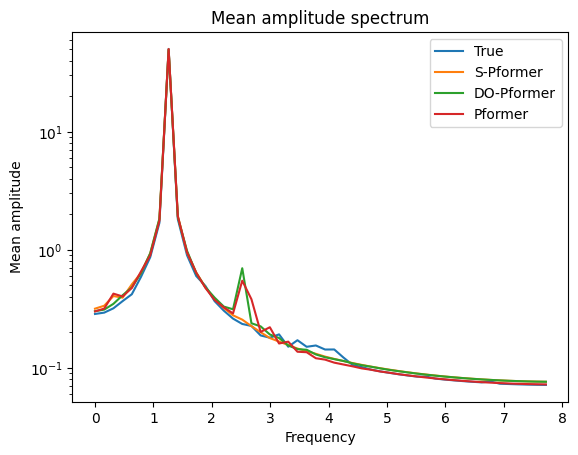

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

x_grid = np.linspace(0, 2 * np.pi, 101)  # x grid points


# assume u_true, sp_pred, do_pred, p_pred are (N×M) arrays where N is grid points
N, M = u.shape
dx = x_grid[1] - x_grid[0]

# compute mean over the second axis so we get a 1D spectrum
def mean_spectrum(u):
    return np.abs(fft(u, axis=0)).mean(axis=1)

spec_true = mean_spectrum(u)
spec_sp   = mean_spectrum(spformer_pred)
spec_do   = mean_spectrum(dopformer_pred)
spec_p    = mean_spectrum(pformer_pred)

freqs = fftfreq(N, d=dx)

plt.figure()
# only positive freqs
half = slice(0, N//2)
plt.semilogy(freqs[half], spec_true[half],   label='True')
plt.semilogy(freqs[half], spec_sp[half],     label='S-Pformer')
plt.semilogy(freqs[half], spec_do[half],     label='DO-Pformer')
plt.semilogy(freqs[half], spec_p[half],      label='Pformer')
plt.xlabel('Frequency')
plt.ylabel('Mean amplitude')
plt.legend()
plt.title('Mean amplitude spectrum')
plt.show()


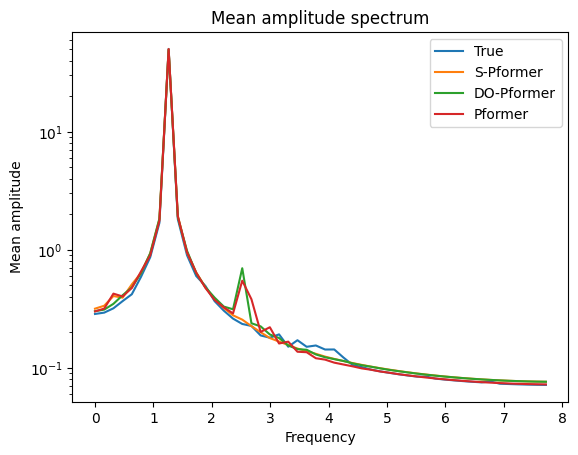

S-Pformer MAE: 0.030395739819741783
DO-Pformer MAE: 0.04693005816872197
Pformer MAE: 0.03142460442815871


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
x_grid = np.linspace(0, 2 * np.pi, 101)  # x grid points

# assume u_true, sp_pred, do_pred, p_pred are (N×M) arrays where N is grid points
N, M = u.shape
dx = x_grid[1] - x_grid[0]

# compute mean over the second axis so we get a 1D spectrum
def mean_spectrum(u):
    return np.abs(fft(u, axis=0)).mean(axis=1)

spec_true = mean_spectrum(u)
spec_sp   = mean_spectrum(spformer_pred)
spec_do   = mean_spectrum(dopformer_pred)
spec_p    = mean_spectrum(pformer_pred)

freqs = fftfreq(N, d=dx)

plt.figure()
# only positive freqs
half = slice(0, N//2)
plt.semilogy(freqs[half], spec_true[half],   label='True')
plt.semilogy(freqs[half], spec_sp[half],     label='S-Pformer')
plt.semilogy(freqs[half], spec_do[half],     label='DO-Pformer')
plt.semilogy(freqs[half], spec_p[half],      label='Pformer')
plt.xlabel('Frequency')
plt.ylabel('Mean amplitude')
plt.legend()
plt.title('Mean amplitude spectrum')
plt.show()

# print MAE for each model spectrum
print("S-Pformer MAE:", np.mean(np.abs(spec_sp[half] - spec_true[half])))
print("DO-Pformer MAE:", np.mean(np.abs(spec_do[half] - spec_true[half])))
print("Pformer MAE:", np.mean(np.abs(spec_p[half] - spec_true[half])))
